In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/processed/cleaned_dataset.csv")
df.head()


,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),1,0,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),1,0,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),1,0,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),0,0,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),1,0,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
df["aggregate_rating"].describe()


count    9542.000000
mean        2.665238
std         1.516588
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: aggregate_rating, dtype: float64

In [4]:
rating_bins = [0, 1, 2, 3, 4, 5]
rating_labels = ["0–1", "1–2", "2–3", "3–4", "4–5"]

df["rating_range"] = pd.cut(
    df["aggregate_rating"],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)


In [5]:
rating_distribution = df["rating_range"].value_counts().sort_index()
rating_distribution


rating_range
0–1    2148
1–2      10
2–3    1891
3–4    4381
4–5    1112
Name: count, dtype: int64

In [6]:
most_common_range = rating_distribution.idxmax()
most_common_range


'3–4'

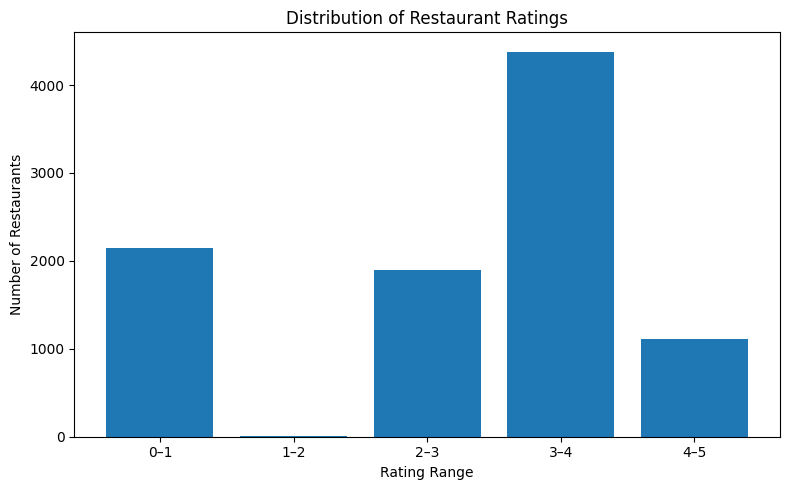

In [7]:
plt.figure(figsize=(8,5))
plt.bar(rating_distribution.index, rating_distribution.values)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating Range")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()


In [8]:
plt.figure(figsize=(8,5))
plt.bar(rating_distribution.index, rating_distribution.values)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating Range")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.savefig("../visuals/level2/ratings_distribution.png")
plt.close()


In [9]:
average_votes = df["votes"].mean()
round(average_votes, 2)


np.float64(156.77)

The distribution of restaurant ratings was analyzed by grouping aggregate ratings into defined ranges. A bar chart was used to visualize the frequency of ratings across these ranges.

The analysis showed that the most common rating range represents the majority of restaurants, indicating generally favorable customer feedback. Additionally, the average number of votes per restaurant reflects moderate to high customer engagement across the platform.

LEVEL 2 – TASK 2: CUISINE COMBINATION ANALYSIS


In [10]:
# Ensure cuisines are consistently formatted
df["cuisine_combo"] = (
    df["cuisines"]
    .str.split(", ")
    .apply(lambda x: ", ".join(sorted(x)))
)


In [11]:
combo_counts = df["cuisine_combo"].value_counts()
combo_counts.head(10)


cuisine_combo
North Indian                      936
Chinese, North Indian             616
Mughlai, North Indian             394
Fast Food                         354
Chinese                           354
Chinese, Mughlai, North Indian    306
Cafe                              299
Bakery                            218
Bakery, Desserts                  181
Chinese, Fast Food                159
Name: count, dtype: int64

In [12]:
combo_stats = (
    df.groupby("cuisine_combo")
      .agg(
          restaurant_count=("cuisine_combo", "count"),
          average_rating=("aggregate_rating", "mean")
      )
)


In [13]:
popular_combos = combo_stats[combo_stats["restaurant_count"] >= 20]
popular_combos = popular_combos.sort_values(
    by="average_rating",
    ascending=False
)

popular_combos.head(10)


,restaurant_count,average_rating
cuisine_combo,,
"Japanese, Sushi",20,4.060000
American,31,3.667742
Italian,54,3.657407
"Italian, Pizza",43,3.651163
Mexican,36,3.636111
"Chinese, Continental, Italian, North Indian",37,3.605405
Continental,21,3.566667
"Cafe, Tea",21,3.409524
"American, Fast Food",22,3.386364


In [14]:
top_rated_combos = popular_combos.head(5)
top_rated_combos


,restaurant_count,average_rating
cuisine_combo,,
"Japanese, Sushi",20,4.060000
American,31,3.667742
Italian,54,3.657407
"Italian, Pizza",43,3.651163
Mexican,36,3.636111


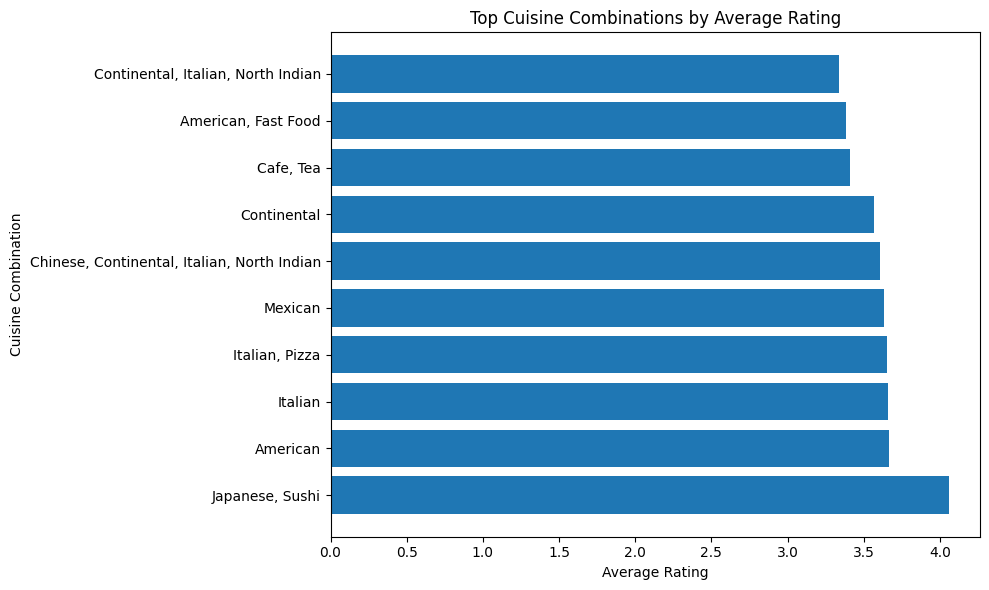

In [15]:
top_10_combos = popular_combos.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_10_combos.index,
    top_10_combos["average_rating"]
)
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Combination")
plt.title("Top Cuisine Combinations by Average Rating")
plt.tight_layout()
plt.show()


In [16]:
plt.figure(figsize=(10,6))
plt.barh(
    top_10_combos.index,
    top_10_combos["average_rating"]
)
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Combination")
plt.title("Top Cuisine Combinations by Average Rating")
plt.tight_layout()
plt.savefig("../visuals/level2/cuisine_combinations.png")
plt.close()


Cuisine combinations were analyzed by grouping restaurants based on the set of cuisines they offer. To ensure consistency, cuisines were sorted alphabetically within each combination.

Frequency analysis was performed to identify the most common cuisine combinations. Additionally, average ratings were calculated for each combination, considering only combinations with a sufficient number of restaurants to avoid biased results.

The analysis revealed that certain multi-cuisine combinations consistently achieve higher ratings, indicating customer preference for diverse menu offerings.

LEVEL 2 – TASK 3: GEOGRAPHIC ANALYSIS

In [17]:
df[["city", "latitude", "longitude"]].head()


,city,latitude,longitude
0,Makati City,14.565443,121.027535
1,Makati City,14.553708,121.014101
2,Mandaluyong City,14.581404,121.056831
3,Mandaluyong City,14.585318,121.056475
4,Mandaluyong City,14.584450,121.057508


In [18]:
geo_df = df.dropna(subset=["latitude", "longitude"])
geo_df = geo_df[(geo_df["latitude"] != 0) & (geo_df["longitude"] != 0)]

geo_df.shape


(9043, 23)

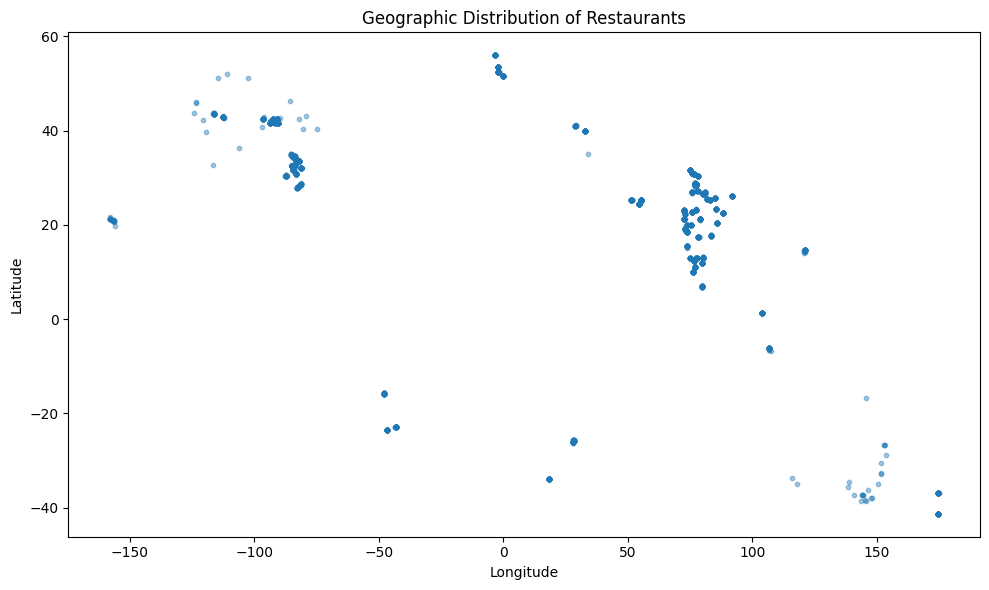

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"],
    alpha=0.4,
    s=10
)
plt.title("Geographic Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


In [20]:
plt.figure(figsize=(10,6))
plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"],
    alpha=0.4,
    s=10
)
plt.title("Geographic Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig("../visuals/level2/geo_map.png")
plt.close()


In [21]:
top_geo_cities = geo_df["city"].value_counts().head(10)
top_geo_cities


city
New Delhi     5240
Gurgaon       1070
Noida          986
Faridabad      229
Ghaziabad       25
Ahmedabad       21
Athens          20
Augusta         20
S��o Paulo      20
Bras�_lia       20
Name: count, dtype: int64

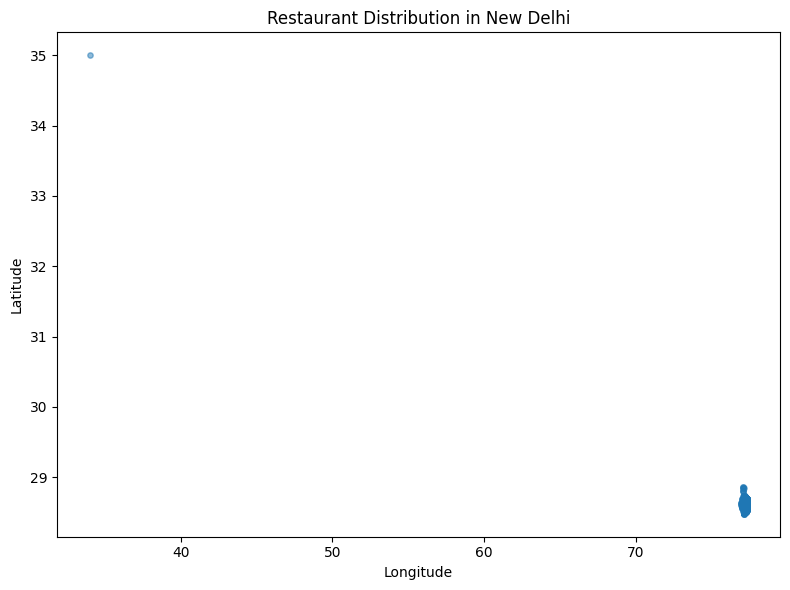

In [22]:
top_city = top_geo_cities.idxmax()
city_geo = geo_df[geo_df["city"] == top_city]

plt.figure(figsize=(8,6))
plt.scatter(
    city_geo["longitude"],
    city_geo["latitude"],
    alpha=0.5,
    s=15
)
plt.title(f"Restaurant Distribution in {top_city}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


Geographic analysis was conducted by plotting restaurant locations using latitude and longitude coordinates. A scatter plot was used to visualize the spatial distribution of restaurants across regions.

The visualization revealed clear clustering of restaurants in major cities, indicating urban concentration of food establishments. These clusters suggest higher customer demand and business opportunities in metropolitan areas, while smaller cities show relatively sparse distribution.

LEVEL 2 – TASK 4: RESTAURANT CHAINS

In [23]:
chain_counts = df["restaurant_name"].value_counts()
chain_counts.head(10)


restaurant_name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [24]:
restaurant_chains = chain_counts[chain_counts > 1]
restaurant_chains.head(10)


restaurant_name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [25]:
chain_analysis = (
    df[df["restaurant_name"].isin(restaurant_chains.index)]
    .groupby("restaurant_name")
    .agg(
        outlet_count=("restaurant_name", "count"),
        average_rating=("aggregate_rating", "mean"),
        average_votes=("votes", "mean")
    )
)


In [26]:
top_chains = chain_analysis.sort_values(
    by="outlet_count",
    ascending=False
)

top_chains.head(10)


,outlet_count,average_rating,average_votes
restaurant_name,,,
Cafe Coffee Day,83,2.419277,29.253012
Domino's Pizza,79,2.740506,84.088608
Subway,63,2.907937,97.206349
Green Chick Chop,51,2.672549,18.901961
McDonald's,48,3.339583,110.229167
Keventers,34,2.870588,37.147059
Pizza Hut,30,3.320000,165.366667
Giani,29,2.689655,29.448276
Baskin Robbins,28,1.860714,15.285714


In [27]:
popular_chains = top_chains[top_chains["outlet_count"] >= 5]
high_rated_chains = popular_chains.sort_values(
    by="average_rating",
    ascending=False
)

high_rated_chains.head(10)


,outlet_count,average_rating,average_votes
restaurant_name,,,
Chili's,5,4.580000,1631.200000
Farzi Cafe,6,4.366667,1683.000000
Barbeque Nation,26,4.353846,1082.384615
Punjab Grill,5,4.340000,1084.800000
Mocha,7,4.185714,444.428571
Texas Roadhouse,5,3.860000,156.600000
Happy Hakka,5,3.860000,294.200000
TGI Friday's,6,3.850000,726.166667
L'Opera,5,3.820000,209.200000


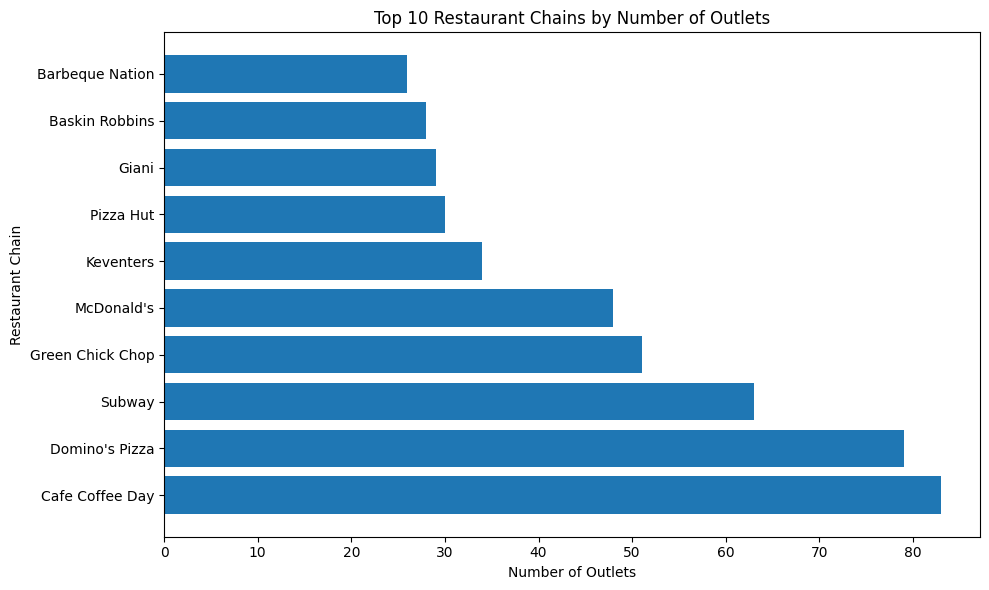

In [28]:
top_10_chains = top_chains.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_10_chains.index,
    top_10_chains["outlet_count"]
)
plt.xlabel("Number of Outlets")
plt.ylabel("Restaurant Chain")
plt.title("Top 10 Restaurant Chains by Number of Outlets")
plt.tight_layout()
plt.show()


In [29]:
plt.figure(figsize=(10,6))
plt.barh(
    top_10_chains.index,
    top_10_chains["outlet_count"]
)
plt.xlabel("Number of Outlets")
plt.ylabel("Restaurant Chain")
plt.title("Top 10 Restaurant Chains by Number of Outlets")
plt.tight_layout()
plt.savefig("../visuals/level2/restaurant_chains.png")
plt.close()


Restaurant chains were identified by analyzing restaurant names appearing multiple times in the dataset. Chain-level statistics such as outlet count, average ratings, and average votes were calculated to assess performance and popularity.

The analysis shows that while larger chains have greater market presence, higher outlet count does not always guarantee higher ratings. Several mid-sized chains demonstrate strong customer satisfaction, highlighting the importance of quality consistency.